<a href="https://colab.research.google.com/github/themehmi/Colab-Files/blob/main/Classification_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classification**



In machine learning, Classification is a type of Supervised Learning where the goal is to predict a discrete label or "class" for a given input. Unlike regression, which predicts continuous numbers (like a house price), classification assigns data into specific categories.

**How It Works**


The algorithm learns from a labeled dataset—meaning it looks at past examples where the "right answer" is already known. It identifies patterns in the features (input data) that distinguish one group from another. Once trained, the model can take a new, unseen observation and map it to one of the predefined categories.

# **Classification Matrics**

To know if your classification model is actually working, you don't just look at accuracy. You often look at:

* Precision: How many of the "positive" predictions were actually correct?

* Recall: How many of the actual "positive" cases did the model find?

* Confusion Matrix: A table used to describe the performance of a model by showing true positives, true negatives, false positives, and false negatives.


Accuracy$\frac{TP + TN}{Total}$ - Overall, how often is the classifier correct?

Precision$\frac{TP}{TP + FP}$ - When it predicts "Positive," how often is it right?

Recall (Sensitivity)$\frac{TP}{TP + FN}$ - How many of the actual "Positive" cases did it catch?

F1 Score$2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ - The harmonic mean of Precision and Recall (good for imbalanced data).

# **Confusion Matrix**



A Confusion Matrix is a specific table layout that allows you to visualize the performance of a classification algorithm. It helps you see not just if your model is making mistakes, but exactly what kind of mistakes it is making.


**The Four Quadrants:**


The matrix consists of four key metrics:

* **True Positive** (TP): You predicted "Positive," and it was actually "Positive." (e.g., You caught a real spam email).

* **True Negative** (TN): You predicted "Negative," and it was actually "Negative." (e.g., A normal email correctly went to your inbox).

* **False Positive** (FP): You predicted "Positive," but it was actually "Negative." (Also known as a Type I Error—e.g., A normal email was wrongly sent to Spam).

* **False Negative** (FN): You predicted "Negative," but it was actually "Positive." (Also known as a Type II Error—e.g., A spam email landed in your inbox).



---


---





<img src="https://i0.wp.com/statisticsbyjim.com/wp-content/uploads/2025/05/confusion_matrix-1.png?fit=550%2C450&ssl=1">

**Importing Libraries**

In [ ]:
# Data manipulation
import pandas as pd

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


**Loading Insurance Dataset**

In [ ]:
#load csv
path="https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/insurance.csv"
df = pd.read_csv(path)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


**Encoding For Non Numeric Columns**

In [ ]:
# encoding on columns

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

In [ ]:
df["smoker"].value_counts()

,count
smoker,
0,1064
1,274


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


**Model Training**

In [ ]:
# separate features and target

df_features = df.drop('smoker', axis=1)
df_target = df['smoker']

In [ ]:
# test train split

X_train, X_test, y_train, y_test = train_test_split(df_features,df_target, test_size=0.2, random_state=42)

In [ ]:
# Model Training
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
#running accuracy test
from sklearn.metrics import accuracy_score
accuracy_score = accuracy_score(y_test, model.predict(X_test))
print(f"{accuracy_score * 100} %")

95.8955223880597 %


In [ ]:
from sklearn.metrics import classification_report
class_report = classification_report(y_test, model.predict(X_test))
print(class_report)

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       214
           1       0.88      0.93      0.90        54

    accuracy                           0.96       268
   macro avg       0.93      0.95      0.94       268
weighted avg       0.96      0.96      0.96       268



**Confusion Matri**x

In [ ]:
from sklearn.metrics import confusion_matrix

cm  = confusion_matrix(y_test, model.predict(X_test))

cm

array([[207,   7],
       [  4,  50]])

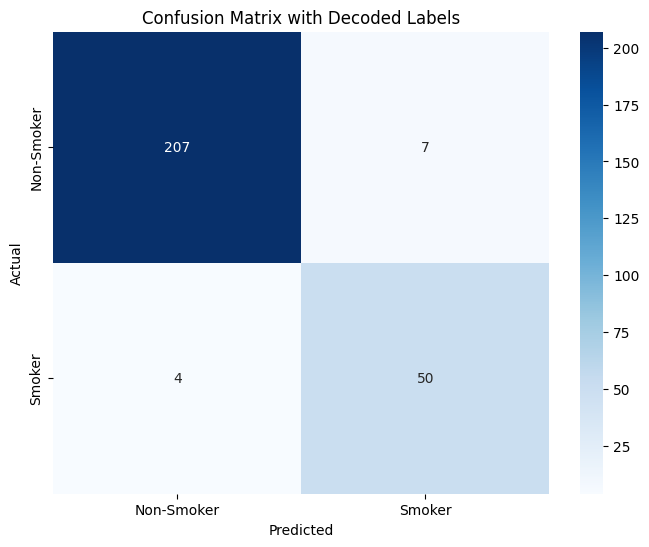

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

smoker_labels = ['Non-Smoker', 'Smoker']

cm = confusion_matrix(y_test, model.predict(X_test))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=smoker_labels, yticklabels=smoker_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix with Decoded Labels')
plt.savefig("confusion_matrix_plot.png")
plt.show()

Replace `some-library-name` with the actual name of the library you want to install. If you want to install a specific version, you can add `==version_number` (e.g., `pip install pandas==1.3.5`).

# Oversampling

Oversampling provides a method to rebalance classes before model training commences. By replicating minority class data points, oversampling balances the playing field and prevents algorithms from disregarding significant yet sparse classes.

Common oversampling techniques include random oversampling, SMOTE (Synthetic Minority Oversampling Technique), and ADASYN (Adaptive Synthetic Sampling Approach for Imbalanced Learning). Random oversampling naively duplicates minority examples, while SMOTE and ADASYN strategically generate synthetic new data to augment real instances.

Notes:


* SMOTE is industry standard

* Use ADASYN when your dataset has a complex decision boundary and the classes are heavily overlapping.

(a). Random Oversampling

In [ ]:
df["smoker"].value_counts()

,count
smoker,
0,1064
1,274


In [ ]:
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE
from collections import Counter

After Oversampling: Counter({1: 1064, 0: 1064})


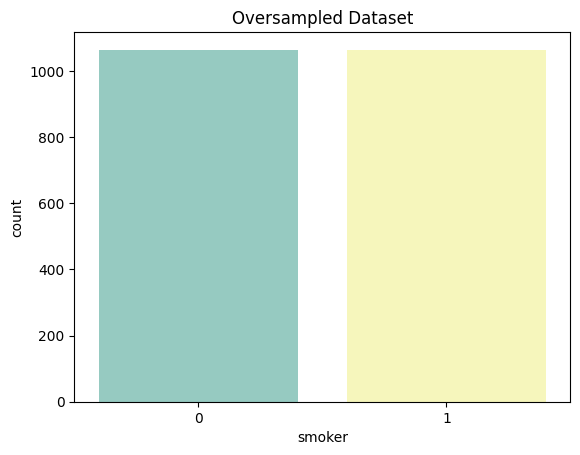

In [ ]:
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(df_features, df_target)
print("After Oversampling:", Counter(y_ros))

sns.countplot(x=y_ros, palette="Set3")
plt.title("Oversampled Dataset")
plt.show()

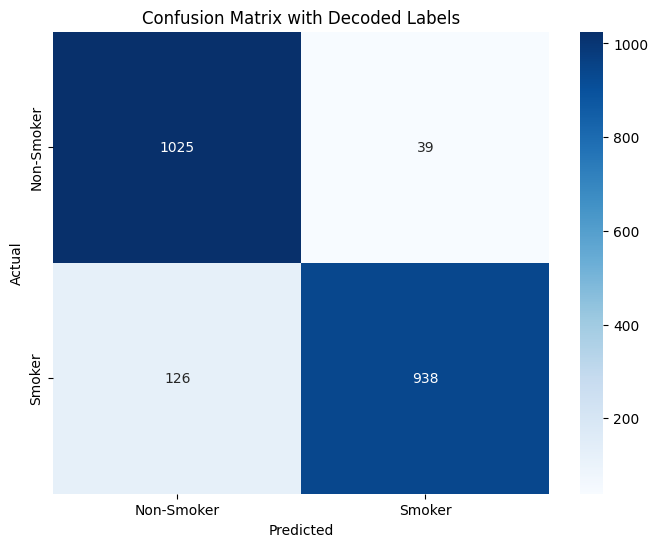

In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

smoker_labels = ['Non-Smoker', 'Smoker']

cm = confusion_matrix(y_ros, model.predict(X_ros))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=smoker_labels, yticklabels=smoker_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix with Decoded Labels')
plt.savefig("confusion_matrix_plot.png")
plt.show()

Originally, dataset was likely imbalanced (1 class had fewer samples). After applying oversampling, both classes now have equal counts:

Class 1: 1064 samples

Class 0: 1064 samples

So your dataset is now perfectly balanced (50–50 split).

In [ ]:
X_ros.duplicated().sum()
# Overfitting might occur

np.int64(791)

✅ Pros

* Fixes class imbalance quickly

* Keeps original data distribution intact

* Works well with many models

⚠️ Cons

* Can cause overfitting (because it repeats the same data points)

* Model may “memorize” duplicated samples instead of learning patterns

**(b) SMOTE (Synthetic Minority Oversampling Technique)**





What is SMOTE?

SMOTE (Synthetic Minority Over-sampling Technique) is a smarter way to balance your dataset compared to RandomOverSampler.

Instead of duplicating existing samples, SMOTE creates new synthetic (artificial) data points for the minority class.

After SMOTE: Counter({1: 1064, 0: 1064})


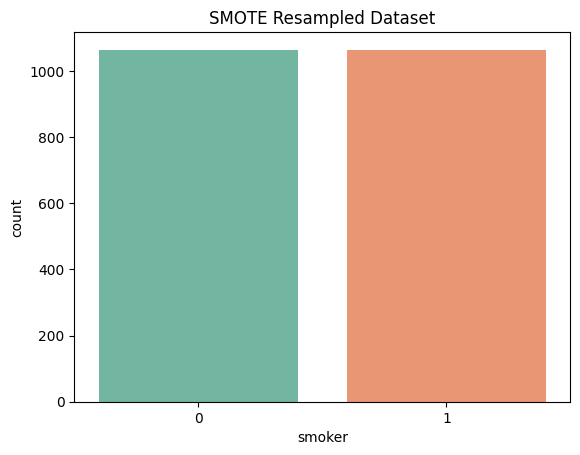

In [ ]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(df_features, df_target)
print("After SMOTE:", Counter(y_smote))

sns.countplot(x=y_smote, palette="Set2")
plt.title("SMOTE Resampled Dataset")
plt.show()

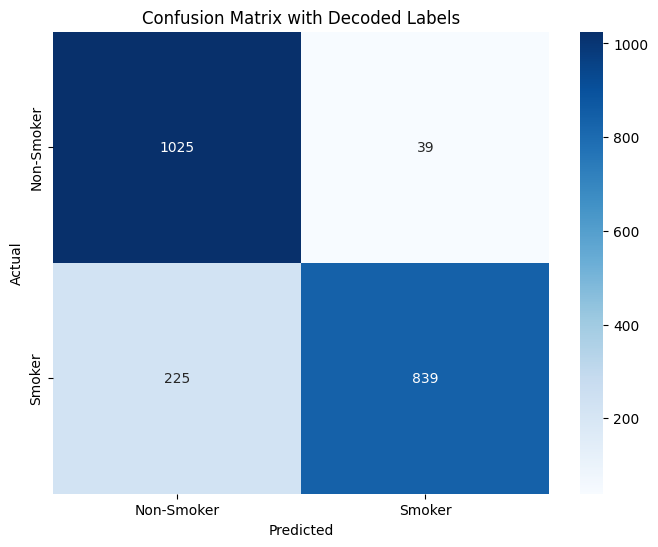

In [ ]:
#confusion matrix for smote
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

smoker_labels = ['Non-Smoker', 'Smoker']

cm = confusion_matrix(y_smote, model.predict(X_smote))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=smoker_labels, yticklabels=smoker_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix with Decoded Labels')
plt.savefig("confusion_matrix_plot.png")
plt.show()

Pros of SMOTE:

* Balances imbalanced datasets → improves minority class prediction

* Creates synthetic samples (not duplicates) → better generalization

* Reduces overfitting compared to simple oversampling

* Works with many ML algorithms and is easy to use

Cons of SMOTE:

* Can generate noisy or unrealistic data

* Risk of overfitting if synthetic samples are too similar

* Ignores majority class → may create class overlap

* Increases dataset size → higher computation time

**Classification Report For RandomOverSampler**

In [ ]:
from sklearn.metrics import classification_report
class_report = classification_report(y_ros, model.predict(X_ros))
print(class_report)

              precision    recall  f1-score   support

           0       0.89      0.96      0.93      1064
           1       0.96      0.88      0.92      1064

    accuracy                           0.92      2128
   macro avg       0.93      0.92      0.92      2128
weighted avg       0.93      0.92      0.92      2128



**Classification Report For SMOTE**

In [ ]:
from sklearn.metrics import classification_report
class_report = classification_report(y_smote, model.predict(X_smote))
print(class_report)

              precision    recall  f1-score   support

           0       0.82      0.96      0.89      1064
           1       0.96      0.79      0.86      1064

    accuracy                           0.88      2128
   macro avg       0.89      0.88      0.87      2128
weighted avg       0.89      0.88      0.87      2128



# **Undersampling**



Undersampling is a data preprocessing technique used in machine learning to balance imbalanced datasets by reducing the number of samples in the majority class. It helps prevent models from becoming biased toward the majority class, although it risks losing valuable information needed for accurate classification.

**1. Random Under-Sampling**

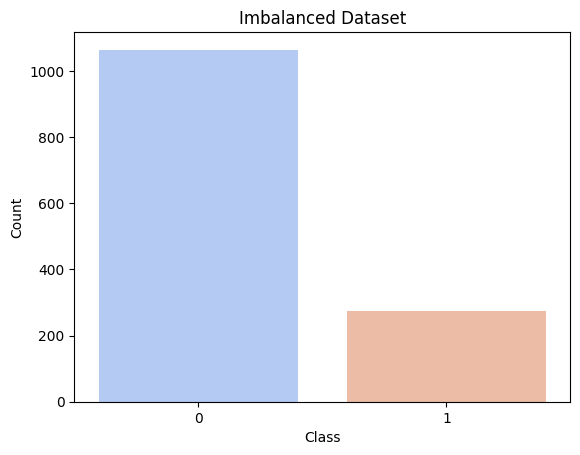

In [ ]:
sns.countplot(x=df['smoker'], palette="coolwarm")
plt.title("Imbalanced Dataset")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
#fix imblance using undersampling
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss

In [ ]:
df_features.value_counts().sum()

np.int64(1338)

In [ ]:
df_target.value_counts().sum()

np.int64(1338)

In [ ]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(df_features, df_target)
print("After Undersampling:", Counter(y_rus))

After Undersampling: Counter({0: 274, 1: 274})


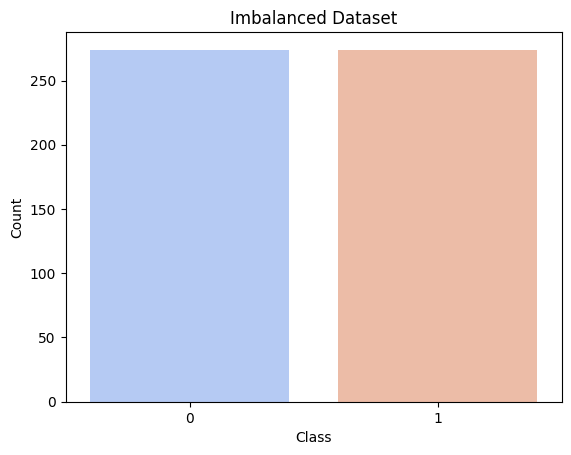

In [ ]:
sns.countplot(x=y_rus, palette="coolwarm")
plt.title("Imbalanced Dataset")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

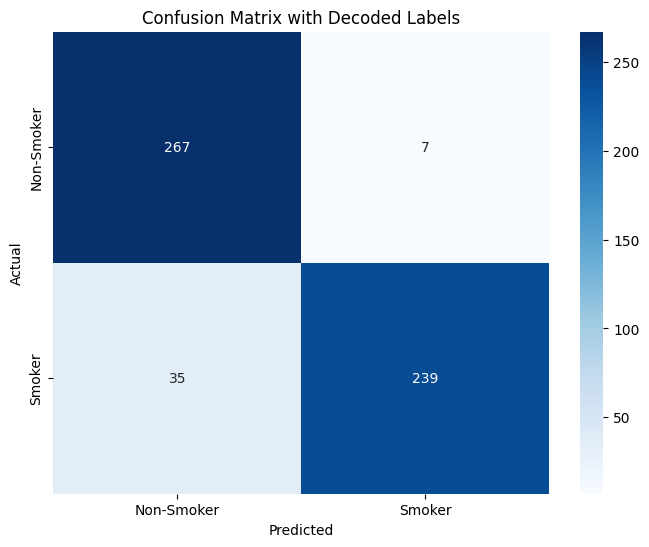

In [ ]:
#confusion matrix for RandomUnderSampling
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

smoker_labels = ['Non-Smoker', 'Smoker']

cm = confusion_matrix(y_rus, model.predict(X_rus))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=smoker_labels, yticklabels=smoker_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix with Decoded Labels')
plt.savefig("confusion_matrix_plot.png")
plt.show()

**Classification Report For RUS**

In [ ]:
from sklearn.metrics import classification_report
class_report = classification_report(y_smote, model.predict(X_smote))
print(class_report)

              precision    recall  f1-score   support

           0       0.82      0.96      0.89      1064
           1       0.96      0.79      0.86      1064

    accuracy                           0.88      2128
   macro avg       0.89      0.88      0.87      2128
weighted avg       0.89      0.88      0.87      2128



**The Pros**
* Speed: Training is much faster because the dataset is smaller.
* Efficiency: Reduces the memory ($RAM$) required to process data.
* Simple: Easy to implement without complex math or synthetic data.

**The Cons**
* Data Loss: You throw away potentially valuable information from the majority class.
* Instability: Since it's random, you might delete the "wrong" samples, leading to high variance in model performance.
* Underfitting: The model may fail to learn the actual complexity of the majority group.



---



---

